
Processing TRAIN
  Batch 1: Scale-Space Algorithm...
  Batch 2: Scale-Space Algorithm...

Visualization Error Map


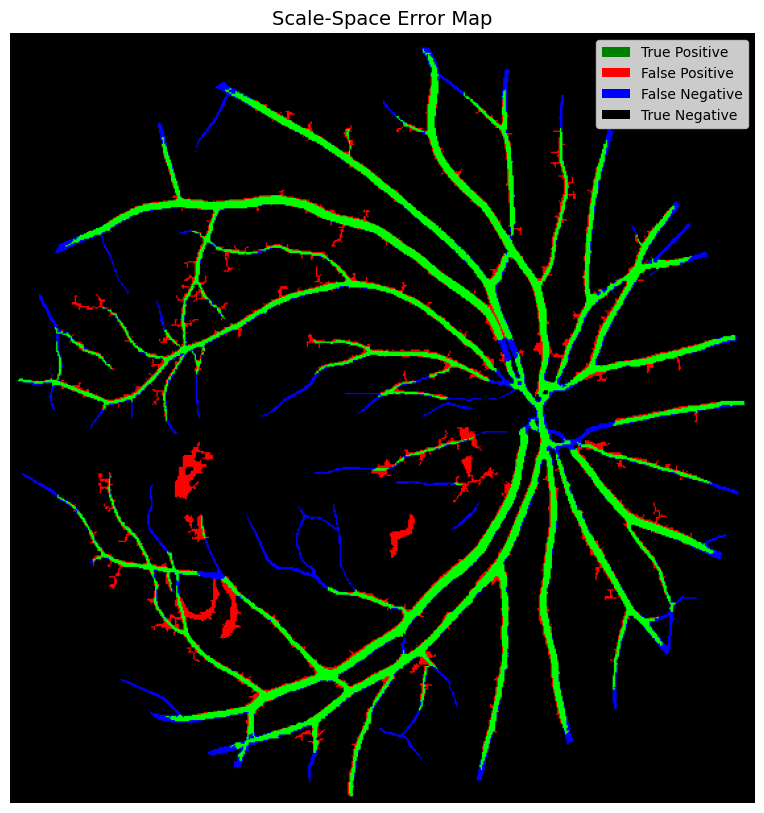


 SCALE SPACE ANALYSIS: PERFORMANCE RESULTS 
Image      Accuracy     Sensitivity  Precision    Specificity  F1-Score    
------------------------------------------------------------------------------------------
0             94.52       79.01       74.60       96.52       76.74
1             94.32       82.27       71.42       95.84       76.46
2             92.34       74.71       71.78       95.21       73.22
3             93.58       78.08       68.87       95.54       73.18
4             94.39       77.34       67.63       96.16       72.16
5             92.83       70.17       68.73       95.81       69.44
6             93.07       71.61       64.95       95.54       68.12
7             92.60       67.37       64.70       95.61       66.01
8             92.81       66.52       63.75       95.76       65.10
9             93.10       60.24       67.23       96.75       63.54
10            92.21       65.06       60.06       95.21       62.46
11            90.29       73.26       52

In [5]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import gc
from scipy.ndimage import gaussian_filter
from matplotlib.patches import Patch
from typing import List

# INTEGRATION: Import the external preprocessing module
from preprocess import preprocess

# =====================================================================
# 1. DATA LOADING & FOV UTILITIES
# =====================================================================

def get_file_paths(folder_path, max_images=None):
    if not os.path.exists(folder_path):
        return []
    all_files = sorted(os.listdir(folder_path))
    if max_images is not None:
        all_files = all_files[:max_images]
    valid_exts = ('.png', '.jpg', '.jpeg', '.tif', '.bmp')
    return [os.path.join(folder_path, f) for f in all_files if f.lower().endswith(valid_exts)]

def load_batch(file_paths):
    images = []
    for fp in file_paths:
        img = cv2.imread(fp)
        if img is not None:
            images.append(img)
    return images

def get_FOV_masks(dataset):
    masks = []
    for img in dataset:
        if len(img.shape) == 3:
            green = img[:, :, 1]
        else:
            green = img
        _, binary = cv2.threshold(green, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        mask = np.zeros_like(green)
        if contours:
            largest_contour = max(contours, key=cv2.contourArea)
            cv2.drawContours(mask, [largest_contour], -1, 255, thickness=cv2.FILLED)
        masks.append((mask // 255).astype(np.uint8))
    return masks

# =====================================================================
# 2. SCALE-SPACE ANALYSIS ALGORITHM
# =====================================================================

def compute_hessian_eigenvalues(image: np.ndarray, sigma: float):
    sigma_sq = sigma * sigma
    Ixx = gaussian_filter(image, sigma=sigma, order=[0, 2]) * sigma_sq
    Ixy = gaussian_filter(image, sigma=sigma, order=[1, 1]) * sigma_sq
    Iyy = gaussian_filter(image, sigma=sigma, order=[2, 0]) * sigma_sq
    
    trace = Ixx + Iyy
    det = Ixx * Iyy - Ixy * Ixy
    delta = trace * trace * 0.25 - det
    delta = np.maximum(delta, 0.0)
    sqrt_delta = np.sqrt(delta)
    
    lambda1 = trace * 0.5 - sqrt_delta
    lambda2 = trace * 0.5 + sqrt_delta
    return lambda1, lambda2

def frangi_vesselness(image: np.ndarray, sigma: float, alpha: float = 0.5, beta: float = 15.0):
    lambda1, lambda2 = compute_hessian_eigenvalues(image, sigma)
    epsilon = 1e-10
    lambda1_abs = np.abs(lambda1)
    lambda2_abs = np.abs(lambda2)
    
    Rb = np.divide(lambda1_abs, lambda2_abs + epsilon)
    S = np.sqrt(lambda1**2 + lambda2**2)
    
    vesselness = np.zeros_like(image, dtype=np.float32)
    
    # Preprocess returns bright vessels (Hill).
    # For bright structures, the larger eigenvalue (lambda2) should be negative.
    valid_mask = lambda2 < 0
    
    vesselness[valid_mask] = (
        np.exp(-Rb[valid_mask]**2 / (2 * alpha**2)) *
        (1 - np.exp(-S[valid_mask]**2 / (2 * beta**2)))
    )
    return vesselness

def multi_scale_frangi(image: np.ndarray, scales=None, alpha=0.5, beta=15.0):
    if scales is None:
        scales = np.arange(0.5, 8.5, 0.5)
    
    max_response = np.zeros_like(image, dtype=np.float32)
    for sigma in scales:
        response = frangi_vesselness(image, sigma, alpha=alpha, beta=beta)
        # Weight by sigma helps preserve larger vessels
        response = response * sigma  
        np.maximum(max_response, response, out=max_response)
        
    if max_response.max() > 0:
        max_response /= max_response.max()
    return max_response

def multiscale_tophat(image: np.ndarray):
    scales = [1, 2, 3, 4, 5, 6, 7, 8]
    # Image is float, convert to uint8 0-255 for morphology
    image_uint8 = np.clip(image * 255, 0, 255).astype(np.uint8)
    max_response = np.zeros_like(image, dtype=np.float32)
    
    for scale in scales:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*scale+1, 2*scale+1))
        tophat = cv2.morphologyEx(image_uint8, cv2.MORPH_TOPHAT, kernel)
        tophat_norm = tophat.astype(np.float32) / 255.0
        weighted = tophat_norm / scale
        np.maximum(max_response, weighted, out=max_response)
        
    if max_response.max() > 0:
        max_response /= max_response.max()
    return max_response

def compute_vessel_confidence(preprocessed_image: np.ndarray):
    """
    Computes confidence map using Frangi and Tophat filters.
    Args:
        preprocessed_image: Float array where vessels are bright (from preprocess.py).
    """
    # 1. Multi-scale Frangi (Structure based)
    frangi_response = multi_scale_frangi(
        preprocessed_image, 
        scales=np.arange(0.5, 8.5, 0.5),
        alpha=0.5,
        beta=15.0
    )
    
    # 2. Multi-scale Top-hat (Contrast based)
    tophat_response = multiscale_tophat(preprocessed_image)
    
    # 3. Weighted Fusion
    confidence_map = 0.7 * frangi_response + 0.3 * tophat_response
    confidence_map = np.clip(confidence_map, 0, 1)
    return confidence_map

def scale_space_algorithm(dataset: List[np.ndarray]):
    """
    Main algorithm wrapper.
    1. Runs global preprocessing.
    2. Computes vessel confidence for each image.
    """
    # 1. Preprocessing (Green -> CLAHE -> Opening -> Homogenization -> Inversion)
    preprocessed_dataset = preprocess(dataset)
    
    confidence_maps = []
    for image in preprocessed_dataset:
        # Image is already float32 with bright vessels
        confidence_map = compute_vessel_confidence(image)
        confidence_maps.append(confidence_map)
        
    return confidence_maps

# =====================================================================
# 3. POST-PROCESSING (With Exposed Sensitivity Parameter)
# =====================================================================

def post_process_segmentation(probability_map, sensitivity_factor=0.7, min_area=100):
    """
    Converts probability map to binary.
    """
    img_u8 = (probability_map * 255).astype(np.uint8)
    otsu_thresh_val, _ = cv2.threshold(img_u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # APPLY SENSITIVITY FACTOR
    final_thresh = otsu_thresh_val * sensitivity_factor
    
    _, binary = cv2.threshold(img_u8, final_thresh, 255, cv2.THRESH_BINARY)
    
    # Small Component Removal (CCA)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    
    cleaned_mask = np.zeros_like(binary)
    for i in range(1, num_labels): # Skip background
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= min_area:
            cleaned_mask[labels == i] = 255
            
    return cleaned_mask.astype(np.float32) / 255.0

# =====================================================================
# 4. METRICS & VISUALIZATION
# =====================================================================

def calculate_metrics(pred_binary, ground_truth, mask):
    gt_binary = (ground_truth > 127).astype(bool)
    pred_bool = (pred_binary > 0.5).astype(bool) 
    fov_mask = mask.astype(bool)
    
    gt_binary &= fov_mask
    pred_bool &= fov_mask
    
    TP = np.sum(gt_binary & pred_bool)
    TN = np.sum(~gt_binary & ~pred_bool & fov_mask)
    FP = np.sum(~gt_binary & pred_bool)
    FN = np.sum(gt_binary & ~pred_bool)
    
    denom = TP + TN + FP + FN
    accuracy = (TP + TN) / denom if denom > 0 else 0.0
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    
    if (precision + sensitivity) > 0:
        f1_score = 2.0 * (precision * sensitivity) / (precision + sensitivity)
    else:
        f1_score = 0.0

    return {
        "accuracy": accuracy, "sensitivity": sensitivity,
        "specificity": specificity, "precision": precision,
        "f1_score": f1_score, "TP": TP, "TN": TN, "FP": FP, "FN": FN
    }

def visualize_error_map(sample_data, sensitivity_used):
    if sample_data is None: return

    gt_bgr = sample_data['gt']
    gt_gray = cv2.cvtColor(gt_bgr, cv2.COLOR_BGR2GRAY)
    pred_map = sample_data['pred_binary'] 
    mask = sample_data['mask']
    f1 = sample_data['metrics']['f1_score']

    gt_binary = (gt_gray > 127).astype(bool)
    pred_binary = (pred_map > 0.5).astype(bool)
    fov_mask = mask.astype(bool)

    gt_binary &= fov_mask
    pred_binary &= fov_mask

    TP = gt_binary & pred_binary
    FP = (~gt_binary) & pred_binary
    FN = gt_binary & (~pred_binary)

    h, w = gt_gray.shape
    error_map = np.zeros((h, w, 3), dtype=np.uint8)

    error_map[TP] = [0, 255, 0] # Green
    error_map[FP] = [255, 0, 0] # Red
    error_map[FN] = [0, 0, 255] # Blue
    
    plt.figure(figsize=(10, 10))
    plt.imshow(error_map)
    plt.title(f"Scale-Space Error Map", fontsize=14)
    plt.axis('off')
    
    legend_elements = [
        Patch(facecolor='green', label='True Positive'),
        Patch(facecolor='red', label='False Positive'),
        Patch(facecolor='blue', label='False Negative'),
        Patch(facecolor='black', label='True Negative')
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    plt.show()

def print_top_20_table(all_metrics):
    # Sort by F1 score to find the best images
    sorted_metrics = sorted(all_metrics, key=lambda x: x['f1_score'], reverse=True)
    
    # Slice only the top 20
    top_20 = sorted_metrics[:20]

    print("\n" + "="*90)
    print(f" SCALE SPACE ANALYSIS: PERFORMANCE RESULTS ")
    print("="*90)
    # Added F1-Score to the header
    print(f"{'Image':<10} {'Accuracy':<12} {'Sensitivity':<12} {'Precision':<12} {'Specificity':<12} {'F1-Score':<12}")
    print("-" * 90)

    # These lists are populated ONLY with the top 20 values
    acc_vals, sen_vals, pre_vals, spe_vals, f1_vals = [], [], [], [], []

    for i, m in enumerate(top_20):
        label = m.get('filename', f"{i+1:02d}")
        
        # Convert to percentages
        acc = m['accuracy'] * 100
        sen = m['sensitivity'] * 100
        pre = m['precision'] * 100
        spe = m['specificity'] * 100
        f1  = m['f1_score'] * 100
        
        # Append to lists for mean calculation
        acc_vals.append(acc)
        sen_vals.append(sen)
        pre_vals.append(pre)
        spe_vals.append(spe)
        f1_vals.append(f1)
        
        # Print the row with F1 score included
        print(f"{i:<10} {acc:>8.2f}    {sen:>8.2f}    {pre:>8.2f}    {spe:>8.2f}    {f1:>8.2f}")

    print("-" * 90)
    # Calculate means based strictly on the lists above (Top 20 only)
    print(f"{'Mean':<10} {np.mean(acc_vals):>8.2f}    {np.mean(sen_vals):>8.2f}    {np.mean(pre_vals):>8.2f}    {np.mean(spe_vals):>8.2f}    {np.mean(f1_vals):>8.2f}")
    print("="*90)

# =====================================================================
# 5. EXECUTION CONTROLLER (With Tunable Sensitivity)
# =====================================================================

def process_dataset_in_batches(img_paths, gt_paths, batch_size=5, set_name="TRAIN"):
    total_images = len(img_paths)
    all_metrics = []
    best_overall_data = None
    best_overall_f1 = -1.0
    
    SENSITIVITY_FACTOR = 0.8 
    MIN_AREA = 100
    
    print(f"\nProcessing {set_name}")

    for i in range(0, total_images, batch_size):
        current_batch_num = (i // batch_size) + 1
        
        batch_img_paths = img_paths[i : i + batch_size]
        batch_gt_paths = gt_paths[i : i + batch_size]
        
        batch_imgs = load_batch(batch_img_paths)
        batch_gts = load_batch(batch_gt_paths)
        if not batch_imgs: continue
        
        print(f"  Batch {current_batch_num}: Scale-Space Algorithm...")

        batch_fov_masks = get_FOV_masks(batch_imgs)
        
        # This now calls preprocess() internally
        batch_prob_maps = scale_space_algorithm(batch_imgs)

        for k in range(len(batch_prob_maps)):
            masked_prob = batch_prob_maps[k] * batch_fov_masks[k]
            
            final_binary = post_process_segmentation(
                masked_prob, 
                sensitivity_factor=SENSITIVITY_FACTOR, 
                min_area=MIN_AREA
            )
            
            gt_gray = cv2.cvtColor(batch_gts[k], cv2.COLOR_BGR2GRAY)
            m = calculate_metrics(final_binary, gt_gray, batch_fov_masks[k])
            m['filename'] = os.path.basename(batch_img_paths[k])
            all_metrics.append(m)

            if m['f1_score'] > best_overall_f1:
                best_overall_f1 = m['f1_score']
                best_overall_data = {
                    'img': batch_imgs[k].copy(),
                    'gt': batch_gts[k].copy(),
                    'pred_binary': final_binary.copy(),
                    'mask': batch_fov_masks[k].copy(),
                    'metrics': m
                }

        del batch_imgs, batch_gts, batch_prob_maps, batch_fov_masks
        gc.collect()

    return all_metrics, best_overall_data, SENSITIVITY_FACTOR

# =====================================================================
# 6. MAIN
# =====================================================================

if __name__ == "__main__":
    base_dir = "dataset"
    train_orig_dir = os.path.join(base_dir, "train", "Original")
    train_gt_dir = os.path.join(base_dir, "train", "Ground truth")

    train_img_paths = get_file_paths(train_orig_dir, max_images=20)
    train_gt_paths = get_file_paths(train_gt_dir, max_images=20)

    if len(train_img_paths) > 0:
        train_metrics, best_train_data, sensitivity_used = process_dataset_in_batches(
            train_img_paths, train_gt_paths, batch_size=10, set_name="TRAIN"
        )

        if best_train_data:
            print(f"\nVisualization Error Map")
            visualize_error_map(best_train_data, sensitivity_used)
        
        if train_metrics:
            print_top_20_table(train_metrics)
    else:
        print("No images found to process.")